# Predicción del Salario de un Beisbolista en función de su rendimiento

In [67]:
# Importar las librerias

# Cargamos nuestras librerias
import numpy as np
import pandas as pd

# Entorno SciKit Learn
from sklearn.tree import DecisionTreeRegressor   # Algortimo CART para árboles.

from sklearn.model_selection import train_test_split  # Dividir el conjunto de prueba y entrenamiento
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score # Validación cruzada
from sklearn.model_selection import cross_validate # Validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

# Para preprocesamiento
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler  # La libreria para reescalar datos

In [24]:
datos=pd.read_csv("hitters.csv")

In [25]:
datos.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [26]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [27]:
# Filtramos solo del 263 casos de beisbolistas donde se conoce el salario
datos=datos[np.isnan(datos.Salary)!=True]

In [28]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64

In [29]:
#Definimos los atributos y el Target
y=datos.Salary
del datos["Salary"]
X=datos


In [30]:
#Recodificar las variables de tipo Objeto.

datos["League"].replace({"A":0,"N":1}, inplace=True)
datos["Division"].replace({"E":0,"W":1}, inplace=True)
datos["NewLeague"].replace({"A":0,"N":1}, inplace=True)

In [31]:
datos.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,1,1,632,43,10,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,0,1,880,82,14,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,1,0,200,11,3,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,1,0,805,40,4,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,0,1,282,421,25,0


In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AtBat      263 non-null    int64
 1   Hits       263 non-null    int64
 2   HmRun      263 non-null    int64
 3   Runs       263 non-null    int64
 4   RBI        263 non-null    int64
 5   Walks      263 non-null    int64
 6   Years      263 non-null    int64
 7   CAtBat     263 non-null    int64
 8   CHits      263 non-null    int64
 9   CHmRun     263 non-null    int64
 10  CRuns      263 non-null    int64
 11  CRBI       263 non-null    int64
 12  CWalks     263 non-null    int64
 13  League     263 non-null    int64
 14  Division   263 non-null    int64
 15  PutOuts    263 non-null    int64
 16  Assists    263 non-null    int64
 17  Errors     263 non-null    int64
 18  NewLeague  263 non-null    int64
dtypes: int64(19)
memory usage: 41.1 KB


In [33]:
# Ajustar un árbol de regresión.
modelo=DecisionTreeRegressor()
scores=cross_val_score(modelo,X,y,scoring="neg_root_mean_squared_error",cv=10,n_jobs=-1)
print("La RMSE es: {:.3f} +/-{:.3f} ".format(-scores.mean(),scores.std()))

La RMSE es: 366.796 +/-86.682 


# Calibración del Algoritmo

In [46]:
# Calibración del modelo... 
espacio_param={"max_depth":[3,4,5,6,7,8,10],"min_samples_leaf":[5,10,15,20]}
# Definimos el modelo que vamos a ajustar
modelo=DecisionTreeRegressor()
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="neg_root_mean_squared_error", 
                              cv=10,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", -modelo_candidato.best_score_)

La mejor configuración fue: {'max_depth': 3, 'min_samples_leaf': 20}
La mejor métrica es: 313.0777278393403


In [43]:
modelo=DecisionTreeRegressor(max_depth=3, min_samples_leaf=10)
modelo.fit(X,y)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=10)

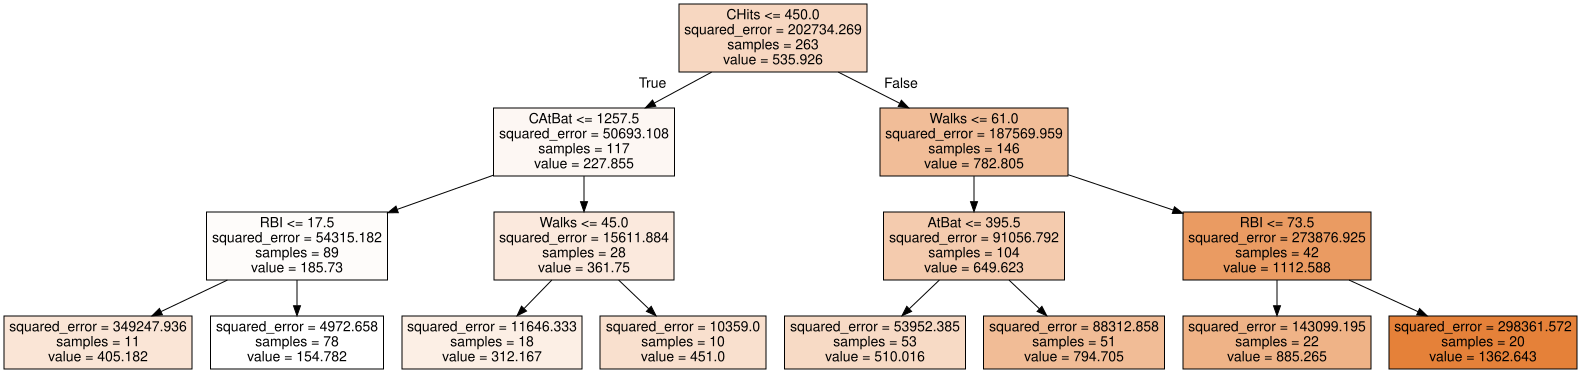

In [44]:
# desde el anaconda prompt (como administradores) ejecutan
# pip install graphviz
import graphviz
from sklearn import tree

dot_data=tree.export_graphviz(modelo,out_file=None,feature_names=X.columns, filled=True)

#Dibujamos el árbol
grafico=graphviz.Source(dot_data,format="png")
grafico

# Calibración del hiperparámetro de la Complejidad

In [61]:
# Calibración del modelo... 
espacio_param={"ccp_alpha":np.linspace(0.01,10,100)}
# Definimos el modelo que vamos a ajustar
modelo=DecisionTreeRegressor()               #<- Cambiamos al criterio de Entropia
c_v=RepeatedKFold(n_splits=10,n_repeats=50)
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="neg_root_mean_squared_error", 
                              cv=c_v,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", -modelo_candidato.best_score_)

La mejor configuración fue: {'ccp_alpha': 3.239090909090909}
La mejor métrica es: 378.15767593490403


In [63]:
modelo=DecisionTreeRegressor(ccp_alpha=3.23909)
modelo.fit(X,y)

DecisionTreeRegressor(ccp_alpha=3.23909)

In [64]:
importancia=pd.DataFrame()
importancia["Atributos"]=X.columns
importancia["importance"]=pd.DataFrame(np.array(modelo.feature_importances_))
importancia.sort_values(by="importance",ascending=False)

,Atributos,importance
8,CHits,0.391976
5,Walks,0.148711
3,Runs,0.094932
17,Errors,0.066892
4,RBI,0.053684
15,PutOuts,0.049034
11,CRBI,0.045125
0,AtBat,0.038415
1,Hits,0.028171
7,CAtBat,0.026058


# Proceso de Reescalamiento..

In [69]:
# Calibración del modelo... 
espacio_param={"decisiontreeregressor__ccp_alpha":np.linspace(0.01,10,100)}
# Definimos el modelo que vamos a ajustar
modelo=make_pipeline(MinMaxScaler(),DecisionTreeRegressor())               #<- Cambiamos al criterio de Entropia
c_v=RepeatedKFold(n_splits=10,n_repeats=50)
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="neg_root_mean_squared_error", 
                              cv=c_v,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", -modelo_candidato.best_score_)

La mejor configuración fue: {'decisiontreeregressor__ccp_alpha': 3.6427272727272726}
La mejor métrica es: 382.3357280682666


In [ ]:
# StandardScaler: 
# La mejor configuración fue: {'decisiontreeregressor__ccp_alpha': 7.477272727272727}
# La mejor métrica es: 378.2648842696972
# RobustScaler:
# La mejor configuración fue: {'decisiontreeregressor__ccp_alpha': 4.550909090909091}
# La mejor métrica es: 377.76270555144873
# MinMaxScaler:
# La mejor configuración fue: {'decisiontreeregressor__ccp_alpha': 3.6427272727272726}
# La mejor métrica es: 382.3357280682666

# Bosque Aleatorio: Random Forest. Bagging 

In [70]:
from sklearn.ensemble import RandomForestRegressor   # Baggin para Árboles

In [71]:
modelo=RandomForestRegressor()
scores=cross_val_score(modelo,X,y,scoring="neg_root_mean_squared_error",cv=10,n_jobs=-1)
print("La RMSE es: {:.3f} +/-{:.3f} ".format(-scores.mean(),scores.std()))

La RMSE es: 271.497 +/-78.829 


In [ ]:
# Falta calibrarlo

In [73]:
# Calibración del modelo... 
espacio_param={"min_samples_leaf":[3,4,5,8,9],
               "max_depth":[2,3,5,6],
              "max_features":[0.3,0.4,0.5,0.7],
              "max_samples":[0.5,0.6,0.7,0.8,0.9]}
# Definimos el modelo que vamos a ajustar
modelo=RandomForestRegressor()              #<- Cambiamos al criterio de Entropia
c_v=RepeatedKFold(n_splits=10,n_repeats=1)
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="neg_root_mean_squared_error", 
                              cv=c_v,n_jobs=-1)
#ajustamos los modelos
modelo_candidato.fit(X,y)
print("La mejor configuración fue:", modelo_candidato.best_params_)
print("La mejor métrica es:", -modelo_candidato.best_score_)

La mejor configuración fue: {'max_depth': 5, 'max_features': 0.7, 'max_samples': 0.7, 'min_samples_leaf': 3}
La mejor métrica es: 268.5206227193341
